# Classification vs. Regression

Both are supervised-learning tasks: a model learns a mapping from input features $X$ to a target $y$. The difference is the type of target and prediction.

| | Classification | Regression |
|---|---|---|
| Target | Discrete category | Continuous number |
| Example | defective / acceptable | remaining useful life |
| Model used here | Logistic regression | Linear regression |
| Typical metrics | Accuracy, precision, recall | MAE, MSE, $R^2$ |

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_regression
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, mean_absolute_error,
    mean_squared_error, r2_score
)
from sklearn.model_selection import train_test_split

%matplotlib inline
plt.style.use('default')
RANDOM_STATE = 42

## 1. Create two example datasets

The classification target contains class labels (`0` or `1`). The regression target can take any real-valued number.

In [22]:
# Two features are useful for drawing a classification boundary.
X_cls, y_cls = make_blobs(
    n_samples=20, centers=[(-2, -2), (2, 2)], cluster_std=1.15,
    random_state=RANDOM_STATE
)

# One feature makes the fitted regression line easy to see.
X_reg, y_reg = make_regression(
    n_samples=20, n_features=1, noise=18,
    random_state=RANDOM_STATE
)

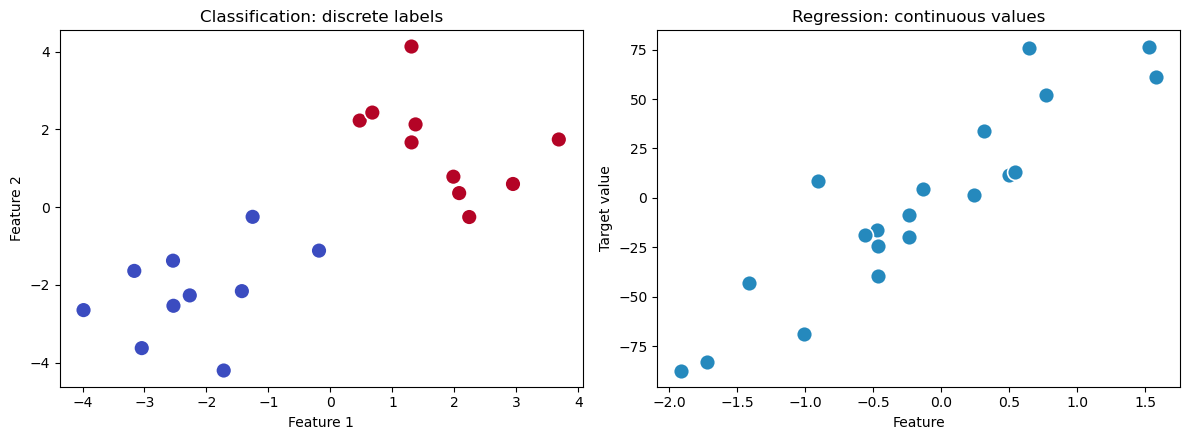

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(
    X_cls[:, 0], X_cls[:, 1], c=y_cls, cmap='coolwarm',
    edgecolor='white', linewidth=1.2, s=130
)
boundary_x = np.array([X_cls[:, 0].min() - 0.5, X_cls[:, 0].max() + 0.5])
axes[0].plot(boundary_x, -boundary_x, '--', color='#a50026', linewidth=2, label='Decision boundary')
axes[0].set(title='Classification: discrete labels', xlabel='Feature 1', ylabel='Feature 2')
axes[0].legend()

axes[1].scatter(X_reg[:, 0], y_reg, color='#2589bd', edgecolor='white', linewidth=1.2, s=130)
axes[1].set(title='Regression: continuous values', xlabel='Feature', ylabel='Target value')

plt.tight_layout()
plt.show()

## 2. Train and evaluate the models

We reserve 25% of each dataset for testing. The models never see these test examples during training.

In [24]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.25, stratify=y_cls, random_state=RANDOM_STATE
)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=RANDOM_STATE
)

classifier = LogisticRegression().fit(Xc_train, yc_train)
regressor = LinearRegression().fit(Xr_train, yr_train)

yc_pred = classifier.predict(Xc_test)
yr_pred = regressor.predict(Xr_test)

In [25]:
print('CLASSIFICATION')
print(f'Accuracy: {accuracy_score(yc_test, yc_pred):.3f}')
print('Predicted labels:', yc_pred[:8])
print('Class-1 probabilities:', classifier.predict_proba(Xc_test[:8])[:, 1].round(3))

print('\nREGRESSION')
print(f'MAE:  {mean_absolute_error(yr_test, yr_pred):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(yr_test, yr_pred)):.2f}')
print(f'R²:   {r2_score(yr_test, yr_pred):.3f}')
print('Predicted values:', yr_pred[:8].round(1))

CLASSIFICATION
Accuracy: 1.000
Predicted labels: [0 0 1 1 0]
Class-1 probabilities: [0.014 0.328 0.942 0.951 0.033]

REGRESSION
MAE:  14.61
RMSE: 21.53
R²:   0.829
Predicted values: [ 30.3  -3.8 -80.8  23.8  -7.9]


## 3. Compare what the fitted models produce

Logistic regression estimates a class probability and converts it into a label using a threshold (normally 0.5). Linear regression directly estimates a numeric value.

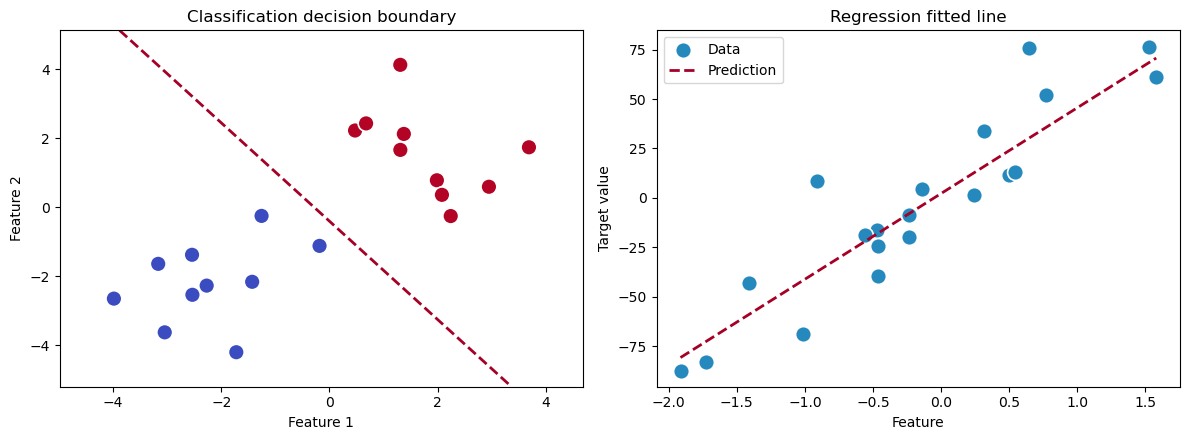

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Classification probability regions and decision boundary.
x0 = np.linspace(X_cls[:, 0].min() - 1, X_cls[:, 0].max() + 1, 250)
x1 = np.linspace(X_cls[:, 1].min() - 1, X_cls[:, 1].max() + 1, 250)
xx0, xx1 = np.meshgrid(x0, x1)
grid = np.c_[xx0.ravel(), xx1.ravel()]
probability = classifier.predict_proba(grid)[:, 1].reshape(xx0.shape)
axes[0].contour(xx0, xx1, probability, levels=[0.5], colors='#a50026', linestyles='--', linewidths=2)
axes[0].scatter(X_cls[:, 0], X_cls[:, 1], c=y_cls, cmap='coolwarm', edgecolor='white', linewidth=1.2, s=130)
axes[0].set(title='Classification decision boundary', xlabel='Feature 1', ylabel='Feature 2')

# Regression fitted line.
x_line = np.linspace(X_reg.min(), X_reg.max(), 200).reshape(-1, 1)
axes[1].scatter(X_reg[:, 0], y_reg, color='#2589bd', edgecolor='white', linewidth=1.2, s=130, label='Data')
axes[1].plot(x_line[:, 0], regressor.predict(x_line), '--', color='#a50026', linewidth=2, label='Prediction')
axes[1].set(title='Regression fitted line', xlabel='Feature', ylabel='Target value')
axes[1].legend()

plt.tight_layout()
plt.show()

## Key takeaway

Choose **classification** when the desired answer is a category. Choose **regression** when the desired answer is a measurable numeric quantity. A model name can be misleading: despite its name, logistic *regression* is primarily a classification algorithm.